![IITIS](pictures/logoIITISduze.png)

# Wyżarzanie równoległe

In [2]:
# Implementation of the algorithm
import random
import numpy as np
from typing import Optional

scaling_func = np.vectorize(lambda x: 2*x-1)

def calculate_gradient(J: np.ndarray, h: np.ndarray, x: np.ndarray, state: np.ndarray, lambda_t: float) -> np.ndarray:
    return state @ J  + state @ J.T + h + lambda_t * x


def calculate_energy(J: np.ndarray, h: np.ndarray, state: np.ndarray):
    return state @ J @ state.T + state @ h 


def parrarel_annealing(J, h, step_size: float, lambda_t_max: float, num_steps: int, 
                       schedule: Optional[np.ndarray] = None, schedule_endpoint: Optional[float] = 0):
    n = len(h)
    x = np.zeros(n)  # stan podstawowy dla H_innit = sum(x**2)
    momentum = np.zeros(n)
    state = scaling_func(np.random.randint(2, size=(n,)))  # losowy stan początkowy

    if schedule is None:
        schedule = np.linspace(lambda_t_max, schedule_endpoint, num=num_steps)

    for k in range(num_steps):
        lambda_t = schedule[k]
        gradient = calculate_gradient(J, h, x, state, lambda_t)
        momentum = (1 - step_size) * momentum - step_size * gradient
        momentum = np.clip(momentum, -1, 1)
        x += momentum
        x = np.clip(x, -1, 1)
        state = np.sign(x)

    return state, calculate_energy(J, h, state)



    


In [3]:
# mała losowa instancja do testowania

n = 5

J = np.triu(np.random.uniform(-1, 1, (n, n)))  # losowa gęsta macierz górnotrójkątna
np.fill_diagonal(J, 0.0)  # Ustawimy diagonale na 0
h = np.random.uniform(-1, 1, n) # losowy wektor

# Potrzebujemy też jakieś niezależny solver. Możemy użyć albo wcześniej zbudowanego, albo gotowaca
from dimod import BinaryQuadraticModel
from dwave.samplers import SimulatedAnnealingSampler

bqm_instance = BinaryQuadraticModel(h, J, vartype="SPIN")
sampler= SimulatedAnnealingSampler()
sampleset = sampler.sample(bqm_instance, num_reads=1)


state, energy = parrarel_annealing(J, h, step_size=0.01, lambda_t_max=10, num_steps=100)

print(sampleset)
print(state, energy)

   0  1  2  3  4    energy num_oc.
0 +1 -1 +1 -1 +1 -3.967717       1
['SPIN', 1 rows, 1 samples, 5 variables]
[-1.  1. -1.  1. -1.] -3.3238503882716812


100%|██████████| 32/32 [00:00<00:00, 34.98it/s]


-469.0


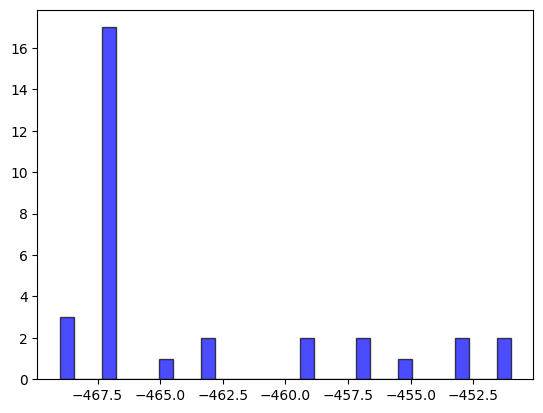

In [4]:
# Działamy na większej instancji
# 216 spinów i geometryczna struktura QPU

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

instance_path = os.path.join("instancje", "Pegasus", "P4_CBFM-P.txt")
# W pliku jest poza samą instancję jeszcze najlepsza znaleziona energia E = -469


def read_instance(path: os.PathLike):
    df = pd.read_csv(path, sep=" ", header=None, comment="#", names=["i", "j", "value"])

    n = max(df[["i", "j"]].max())
    h = np.zeros(n)
    J = np.zeros((n, n))
    
    for row in df.itertuples():
        if row.i == row.j:
            h[row.i - 1] = row.value
        elif row.i > row.j:
            J[row.j - 1, row.i - 1] = row.value  # by zachować górnotrójkątność
        else:
            J[row.i - 1, row.j - 1] = row.value
            
    return J, h

    
J, h = read_instance(instance_path)
num_trajectories = 2 ** 5
energies = []

for _ in tqdm(range(num_trajectories)):
    state, energy = parrarel_annealing(J, h, step_size=0.01, lambda_t_max=10, num_steps=1000)
    energies.append(energy)

print(min(energies))

plt.hist(energies, bins=num_trajectories, color='blue', edgecolor='black', alpha=0.7)
plt.show()


In [5]:
# ładne wykresy

In [6]:
# Wyżarzanie równoległe wiele trajektorii
# To jest w sumie powinnop się nazywać parrarel annealing

# Ważne, zmieniamy wektory z wierszowych na kolumnowe, oraz będziemy liczyć całe macierze

def calculate_gradient_column(J: np.ndarray, h: np.ndarray, x: np.ndarray, state: np.ndarray, lambda_t: float, num_trajectories: int) -> np.ndarray:
    return J @ state + J.T @ state + np.stack([h] * num_trajectories, axis=1) + lambda_t * x


def calculate_energy_column(J: np.ndarray, h: np.ndarray, state: np.ndarray, num_trajectories: int):
    hamiltonian = np.zeros(num_trajectories)
    for t in range(num_trajectories):
        hamiltonian[t] = state[:, t].T @ J @ state[:, t] + state[:, t].T @ h
    #return state.T @ J @ state + state.T @ h
    return hamiltonian


def get_best_solution(states, energies):
    best_energy = np.min(energies)
    best_energy_index = np.argmin(energies)
    best_state = states[:, best_energy_index]
    return best_state, best_energy

def parrarel_annealing_multiple_trajectores(J, h, step_size: float, lambda_t_max: float, num_steps: int, num_trajectories: int,
                       schedule: Optional[np.ndarray] = None, schedule_endpoint: Optional[float] = 0):
    n = len(h)
    x = np.zeros((n, num_trajectories))  # stan podstawowy dla H_innit = sum(x**2)
    momentum = np.zeros((n, num_trajectories))
    state = scaling_func(np.random.randint(2, size=(n, num_trajectories)))  # losowy stan początkowy

    if schedule is None:
        schedule = np.linspace(lambda_t_max, schedule_endpoint, num=num_steps)

    for k in tqdm(range(num_steps), desc="wyżarzanie równoległe"):
        lambda_t = schedule[k]
        gradient = calculate_gradient_column(J, h, x, state, lambda_t, num_trajectories)
        momentum = (1 - step_size) * momentum - step_size * gradient
        momentum = np.clip(momentum, -1, 1)
        x += momentum
        x = np.clip(x, -1, 1)
        state = np.sign(x)

    return state, calculate_energy_column(J, h, state, num_trajectories)




In [7]:
n = 50

J = np.triu(np.random.uniform(-1, 1, (n, n)))  # losowa gęsta macierz górnotrójkątna
np.fill_diagonal(J, 0.0)  # Ustawimy diagonale na 0
h = np.random.uniform(-1, 1, n) # losowy wektor

# Potrzebujemy też jakieś niezależny solver. Możemy użyć albo wcześniej zbudowanego, albo gotowaca
from dimod import BinaryQuadraticModel
from dwave.samplers import SimulatedAnnealingSampler

bqm_instance = BinaryQuadraticModel(h, J, vartype="SPIN")
sampler= SimulatedAnnealingSampler()
sampleset = sampler.sample(bqm_instance, num_reads=1)


state, energy = parrarel_annealing_multiple_trajectores(J, h, step_size=0.01, lambda_t_max=10, num_steps=100, num_trajectories=10)
best_state, best_energy = get_best_solution(state, energy)

print(sampleset)
print(best_state)
print(best_energy)

wyżarzanie równoległe: 100%|██████████| 100/100 [00:00<00:00, 20680.95it/s]

   0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 ... 49     energy num_oc.
0 -1 +1 -1 +1 -1 -1 -1 -1 -1 +1 -1 +1 -1 +1 -1 -1 -1 ... -1 -151.12906       1
['SPIN', 1 rows, 1 samples, 50 variables]
[ 1. -1.  1. -1.  1.  1. -1. -1.  1. -1.  1.  1.  1. -1.  1.  1. -1. -1.
 -1.  1.  1.  1. -1.  1.  1.  1. -1.  1. -1.  1. -1.  1.  1. -1.  1. -1.
 -1.  1.  1.  1. -1.  1.  1. -1.  1.  1.  1. -1.  1.  1.]
-158.02259119582268


In [10]:
J, h = read_instance(instance_path)

states, energies = parrarel_annealing_multiple_trajectores(J, h, step_size=0.01, lambda_t_max=10, num_steps=1000, num_trajectories=32)
best_state, best_energy = get_best_solution(states, energies)

print(best_energy)

wyżarzanie równoległe: 100%|██████████| 1000/1000 [00:00<00:00, 6002.91it/s]

-469.0


In [9]:
# Pełen pegaz

# E = -12772
# best found -12736 steps 10^4 trajectories 2^10

full_pegasus = os.path.join("instancje", "Pegasus", "P16_CBFM-P.txt")
J, h = read_instance(full_pegasus)

states, energies = parrarel_annealing_multiple_trajectores(J, h, step_size=0.01, lambda_t_max=10, num_steps=10000, num_trajectories=2**10)
best_state, best_energy = get_best_solution(states, energies)

print(best_energy)

wyżarzanie równoległe:   0%|          | 35/10000 [00:22<1:46:37,  1.56it/s]


KeyboardInterrupt: 

-371.0


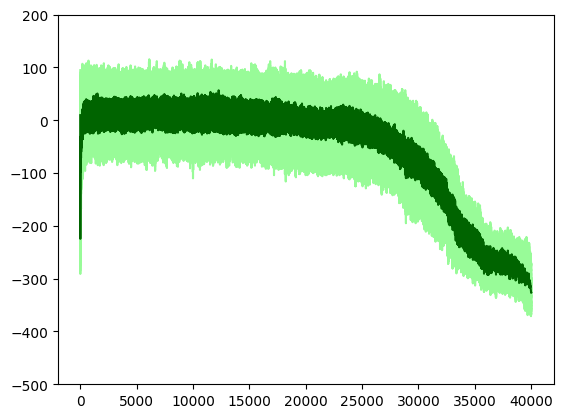

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# parameter chosing
numTrials = 100
numIterations = 40000   # predefined number of iterations
numSpins = 216  # number of spins (Problem size N)
adpRate = 0.02    # learning rate/step size
lamda = np.linspace(10,0,numIterations)     # coefficient of initial Hamiltonian

# initilization
spinVector = np.random.randint(2,size=(numSpins,numTrials))*2-1.0   # randomly initialize spin configurations
xVector = np.zeros((numSpins,numTrials))    # zero initialize classical "superposition"
momentum = np.zeros((numSpins,numTrials))    # zero initialize momentum
isingHamil = np.zeros(numTrials)    # Ising Hamiltonian
isingHamilHistory = np.zeros((numIterations,numTrials))  # Ising Hamiltonian History

coulpingMatrix = J
externalFields = np.stack([h] * numTrials, axis=1)  

# run
for ii in np.arange(numIterations):
    delHising = np.dot(coulpingMatrix, spinVector) + externalFields    # can be implemented experimentally by memristor crossbar array
    delHinit = xVector
    delHsystem = delHising + lamda[ii]*delHinit
    momentum = (1-2*adpRate)*momentum - adpRate*delHsystem    # update momentum
    momentum = np.clip(momentum,-1,1)   # clip momentum
    xVector += momentum     # update classical "superposition"
    xVector = np.clip(xVector,-1,1 )    # clip classical "superposition"
    spinVector = np.sign(xVector)
    for tt in np.arange(numTrials):  
        isingHamil[tt] = np.dot(spinVector[:,tt].T, (coulpingMatrix @ spinVector[:,tt])) + spinVector[:,tt].T @ externalFields[:, tt]   # calculate Ising Hamiltonian
    isingHamilHistory[ii] = isingHamil      # energy tracking

for tt in np.arange(numTrials): 
    plt.plot(isingHamilHistory[:,tt], color = 'palegreen')
plt.plot(np.mean(isingHamilHistory,axis=1), color='darkgreen')
plt.ylim(-500,200)

print(np.min(isingHamilHistory))
